### Boundary Value Problem (BVP) and Shooting Method

As we have already noted, modelling **realistic projectile motion** in two dimensions leads to **two second-order ODEs**. A numerical solution of this system typically needs **four initial conditions**, for example:

- $x(0)=0$
- $y(0)=0$
- $v(0)=v_0$
- $\theta(0)=\theta_0$

We now reformulate the same problem as a **boundary value problem (BVP)**. Instead of specifying all four quantities at $t=0$, we replace one of the initial conditions with a condition imposed at a later time. For instance, we may prescribe the range $R$ by requiring:

- $x(0)=0$
- $y(0)=0$
- $v(0)=v_0$
- $x(t_f)=R$

Here, $R$ denotes the **horizontal range** of the projectile.

To solve this boundary value problem using the **shooting method**, we treat the unknown launch angle $\theta$ as the parameter to be found. We:

1. **Guess** a value of the initial angle, say $\theta=\theta^{(0)}$.
2. **Integrate** the initial value problem (using the other initial conditions) to compute the resulting range, call it $R(\theta^{(0)})$ (sometimes written as $R_0$ for the range obtained from the current guess).
3. **Update** the guess for $\theta$ using the **bisection method** until the boundary condition on the range is satisfied.

A convenient way to write the target condition is as a root-finding problem:
$$
F(\theta) = R(\theta) - R = 0,
$$
i.e. we adjust $\theta$ until the computed range equals the desired range $R$.

## Projectile with quadratic air resistance

The equations of motion of a projectile are

$$
m\frac{d^2x}{dt^2}=F_x,
\qquad
m\frac{d^2y}{dt^2}=-mg+F_y,
$$

where $m$ is the mass and $v$ is the speed of the object. For quadratic air resistance, the drag-force components are

$$
F_x=-D\,v\,v_x,\qquad F_y=-D\,v\,v_y,
$$

with the speed
$$
v=\sqrt{v_x^2+v_y^2}.
$$

Dividing by $m$ and defining $k=\dfrac{D}{m}$ gives the coupled system

$$
\frac{d^2x}{dt^2}=-k\,v\,v_x,
\qquad
\frac{d^2y}{dt^2}=-g-k\,v\,v_y,
$$

where $k=3.89\times 10^{-5}\ \text{m}^{-1}$ and $g=9.81\ \text{m s}^{-2}$.


Introducing the variables
$$
v_x=\frac{dx}{dt},\qquad v_y=\frac{dy}{dt}.
$$

Then the system becomes four first-order ODEs:

$$
\frac{dx}{dt}=v_x,
\qquad
\frac{dy}{dt}=v_y,
$$

$$
\frac{dv_x}{dt}=-k\,v\,v_x,
\qquad
\frac{dv_y}{dt}=-g-k\,v\,v_y,
\qquad
v=\sqrt{v_x^2+v_y^2}.
$$

### Given data

- Initial speed: $v_0=650\ \text{m/s}$
- Drag parameter: $k=\dfrac{D}{m}=3.89\times 10^{-5}\ \text{m}^{-1}$
- Target horizontal distance (range): $R=18000\ \text{m}$

### Numerical task (shooting idea)

Choose a launch angle $\theta$ (unknown), and set initial conditions

$$
x(0)=0,\quad y(0)=0,\quad v_x(0)=v_0\cos\theta,\quad v_y(0)=v_0\sin\theta.
$$

Integrate the ODEs forward in time until the projectile lands (when $y(t_f)=0$ on the way down). The computed range is then

$$
R(\theta)=x(t_f).
$$

Adjust $\theta$ (for example using bisection) until the boundary condition is satisfied:

$$
R(\theta)-R=0,
\quad\text{with}\quad R=18000\ \text{m}.
$$

## Bisection method (general idea)

The **bisection method** is a simple and reliable numerical technique for finding a root of an equation

$$
f(x)=0.
$$

### Key requirement
Bisection works when you can find an interval $[a,b]$ such that the function changes sign across the ends:

$$
f(a)\,f(b) < 0.
$$

A sign change implies (for a continuous function) that there is at least one root in the interval.

### Algorithm
1. Choose an initial interval $[a,b]$ with $f(a)f(b)<0$.
2. Compute the midpoint
   $$
   c=\frac{a+b}{2}.
   $$
3. Evaluate $f(c)$.
4. Replace the interval by the half that still contains the sign change:
   - If $f(a)f(c)<0$, set $b=c$.
   - Otherwise, set $a=c$.
5. Repeat steps 2–4 until the root is found to the desired accuracy.

### Stopping criteria
Common choices are:
- $|f(c)| < \varepsilon$ (function value is close to zero), or
- $\dfrac{b-a}{2} < \varepsilon$ (interval is sufficiently small).

### Why it is useful
- **Guaranteed convergence** (as long as $f$ is continuous and the initial bracket has a sign change).
- Very easy to implement.


25.5
The approximated initial angle is 25.5 degree converged in 1 iterations


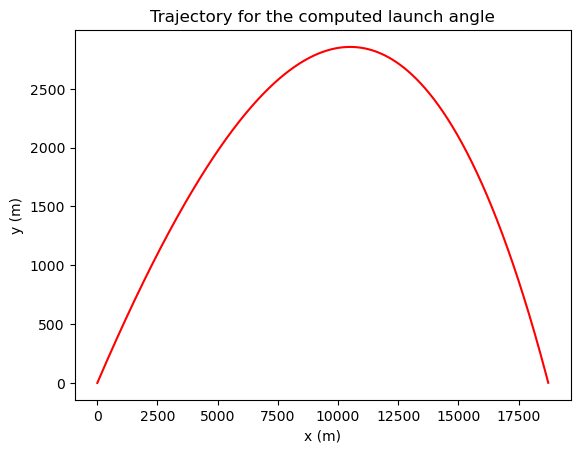

In [5]:
#Solution of a realistic projectile motion as a boundary value problem
import math
import numpy as np
import matplotlib.pyplot as plt

def f1(t, vx, vy, d): return -d*vx*math.sqrt(vx**2+vy**2)
def f2(t, x, vx): return vx
def f3(t, vx, vy, d, g): return -g-d*vy*math.sqrt(vx**2+vy**2)
def f4(t, y, vy): return vy

def project(t, x, y, vx, vy, h, d, g):
    vx += h*f1(t, vx, vy, d)
    x  += h*f2(t, x, vx)
    vy += h*f3(t, vx, vy, d, g)
    y  += h*f4(t, y, vy)
    t  += h
    return [t, x, y, vx, vy]

a = 1*math.pi/180
b = 50*math.pi/180
R = 25000

def shooting(a, b, R):
    v0 = 650
    g = 9.81
    d = 3.89/10**5
    error = 10**(-3)
    count = 0

    def f(z):
        t, x, y, vx, vy, h = 0, 0, 0, v0*math.cos(z), v0*math.sin(z), 0.01
        projectile = open("projectile shooting.txt", "w")
        while (y > -0.000001):
            projectile.write(str(x)+','+str(y)+' \n')
            [t, x, y, vx, vy] = project(t, x, y, vx, vy, h, d, g)
        projectile.close()
        return x

    c = (a+b)/2
    R3 = f(c)

    while abs(R3-R) > 0:
        print(c*180/math.pi)
        count += 1
        R1 = f(a)
        R2 = f(b)

        if R3-R < 0 and R1-R < 0:
            a = c
        elif R3-R > 0 and R1-R > 0:
            a = c

        if R3-R < 0 and R2-R < 0:
            b = c
        elif R3-R > 0 and R2-R > 0:
            b = c

        c = (a+b)/2

        if abs(R3-f(c)) <= error:
            break

        R3 = f(c)

    return [count, c*180/math.pi]

S = shooting(a, b, R)
print("The approximated initial angle is "+str(S[1])+" degree converged in "
      +str(S[0])+" iterations")

# ---- Plot the trajectory from the last run (file already written) ----
X, Y = np.loadtxt("projectile shooting.txt", delimiter=",", unpack=True)
plt.plot(X, Y, "r-")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Trajectory for the computed launch angle")
plt.show()

25.5
13.25
19.375
16.3125
17.84375
17.078125
16.6953125
16.50390625
16.408203125
16.360351562500004
16.336425781250004
16.324462890625004
16.318481445312504
16.321472167968754
16.32296752929688
16.32371520996094
16.32334136962891
16.323154449462894
16.323060989379886
16.32310771942139
16.32308435440064
16.323096036911018
The approximated initial angle is 16.323101878166206 degree converged in 22 iterations


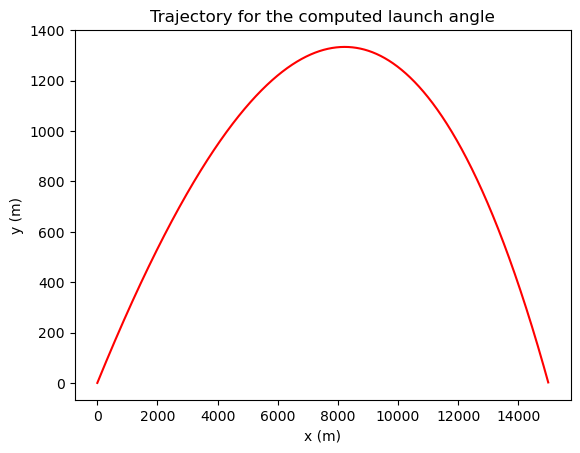

In [9]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

v0 = 650.0
g = 9.81
d = 3.89e-5
R = 15000

a = 1 * math.pi/180
b = 50 * math.pi/180

def rhs(t, z):
    x, y, vx, vy = z
    v = math.sqrt(vx*vx + vy*vy)
    return [vx, vy, -d*v*vx, -g - d*v*vy]

def hit_ground(t, z):
    return z[1]

hit_ground.terminal = True
hit_ground.direction = -1

def range_for_angle(theta):
    z0 = [0.0, 0.0, v0*math.cos(theta), v0*math.sin(theta)]
    sol = solve_ivp(rhs, (0.0, 500.0), z0, events=hit_ground, max_step=0.05)
    if sol.t_events[0].size > 0:
        return sol.y_events[0][0][0]
    return sol.y[0, -1]

def shooting(a, b, R):
    tol = 1e-3
    count = 0
    Fa = range_for_angle(a) - R
    Fb = range_for_angle(b) - R
    if Fa * Fb > 0:
        raise ValueError("Choose a,b so that range(a)-R and range(b)-R have opposite signs.")
    c = 0.5 * (a + b)
    Fc = range_for_angle(c) - R
    while abs(Fc) > tol:
        print(c * 180 / math.pi)
        count += 1
        if Fa * Fc < 0:
            b, Fb = c, Fc
        else:
            a, Fa = c, Fc
        c = 0.5 * (a + b)
        Fc = range_for_angle(c) - R
    return [count, c * 180 / math.pi, c]

S = shooting(a, b, R)
print("The approximated initial angle is " + str(S[1]) + " degree converged in " + str(S[0]) + " iterations")

theta = S[2]
z0 = [0.0, 0.0, v0*math.cos(theta), v0*math.sin(theta)]
t_eval = np.arange(0.0, 500.0, 0.02)

sol = solve_ivp(rhs, (0.0, 500.0), z0, t_eval=t_eval, events=hit_ground, max_step=0.05)
x, y = sol.y[0], sol.y[1]
mask = y >= 0
plt.plot(x[mask], y[mask], "r-")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Trajectory for the computed launch angle")
plt.show()

Reference: Lohar, D. (2019) Computational Methods for Physics. 1st edn. Kolkata, West Bengal:  Medtech. 